In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import sklearn
import pandas as pd
import sys
import torch


print(sys.version_info)
for module in mpl, np, pd, sklearn, torch:
    print(module.__name__, module.__version__)
    
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)

sys.version_info(major=3, minor=12, micro=3, releaselevel='final', serial=0)
matplotlib 3.10.8
numpy 2.4.3
pandas 3.0.1
sklearn 1.8.0
torch 2.10.0+cu128
cuda:0


使用Dataset

In [2]:
from torch.utils.data import Dataset

class RandomDataset(Dataset):
    def __init__(self, labels):
        self.labels = labels
        
    def __getitem__(self, index):
        data = torch.mul(torch.randn(2), 0.1) + self.labels[index] 
        # 生成两个服从标准正态分布的随机数（两个维度), 然后乘以0.1, 再加上label
        label = self.labels[index]
        return data, label 
        # 返回的是一个元组,这里返回的数据格式决定遍历这个数据集时, 每次迭代返回的数据格式
    
    def __len__(self):
        return len(self.labels)
    # 自定义数据集必须要有__len__和__getitem__
rd = RandomDataset(np.random.randint(2, size=1000))
# 生成了一个长度为1000的随机标签数组, 每个元素都是0或1, 传入__init__
print("数据集的长度：", len(rd))

for x,y in rd:
    print(x,y)
    break

数据集的长度： 1000
tensor([1.0920, 0.9687]) 1


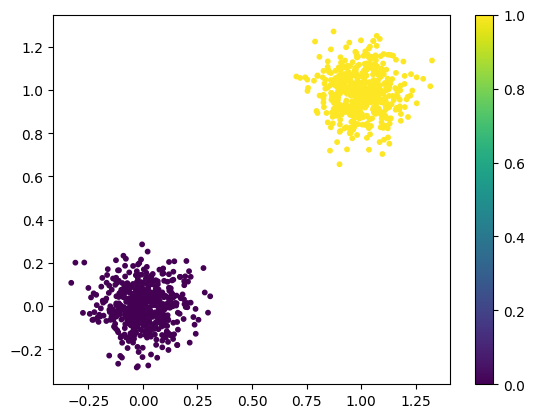

In [3]:
x1 = []
x2 = []
labels = []

for (a,b), label in rd:
    x1.append(a)
    x2.append(b)
    labels.append(label)

    
plt.scatter(x1, x2, s=10, c=labels) # s是点的大小，c是颜色
plt.colorbar()
plt.show()

# Dataloader

In [4]:
from torch.utils.data import DataLoader

ld = DataLoader(rd, batch_size=8, shuffle=True) # batch_size是每次迭代返回的数据个数，shuffle是是否打乱数据集

for data, label in ld:
    print(data)
    print(label)
    break

tensor([[ 0.0946, -0.0479],
        [ 0.9796,  0.8559],
        [-0.1192,  0.0159],
        [-0.1646, -0.0411],
        [ 1.0373,  1.0703],
        [ 1.0485,  1.2193],
        [ 0.9510,  1.0661],
        [ 1.0209,  1.0344]])
tensor([0, 1, 0, 0, 1, 1, 1, 1], dtype=torch.int32)
